## 1. KNN for classification and regression



a) Use KNN to classify iris dataset 


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


(np.float64(2.998746726307124e-16),
 np.float64(0.9999999999999998),
 np.float64(-0.026200181679167715),
 np.float64(0.9999349444958894))

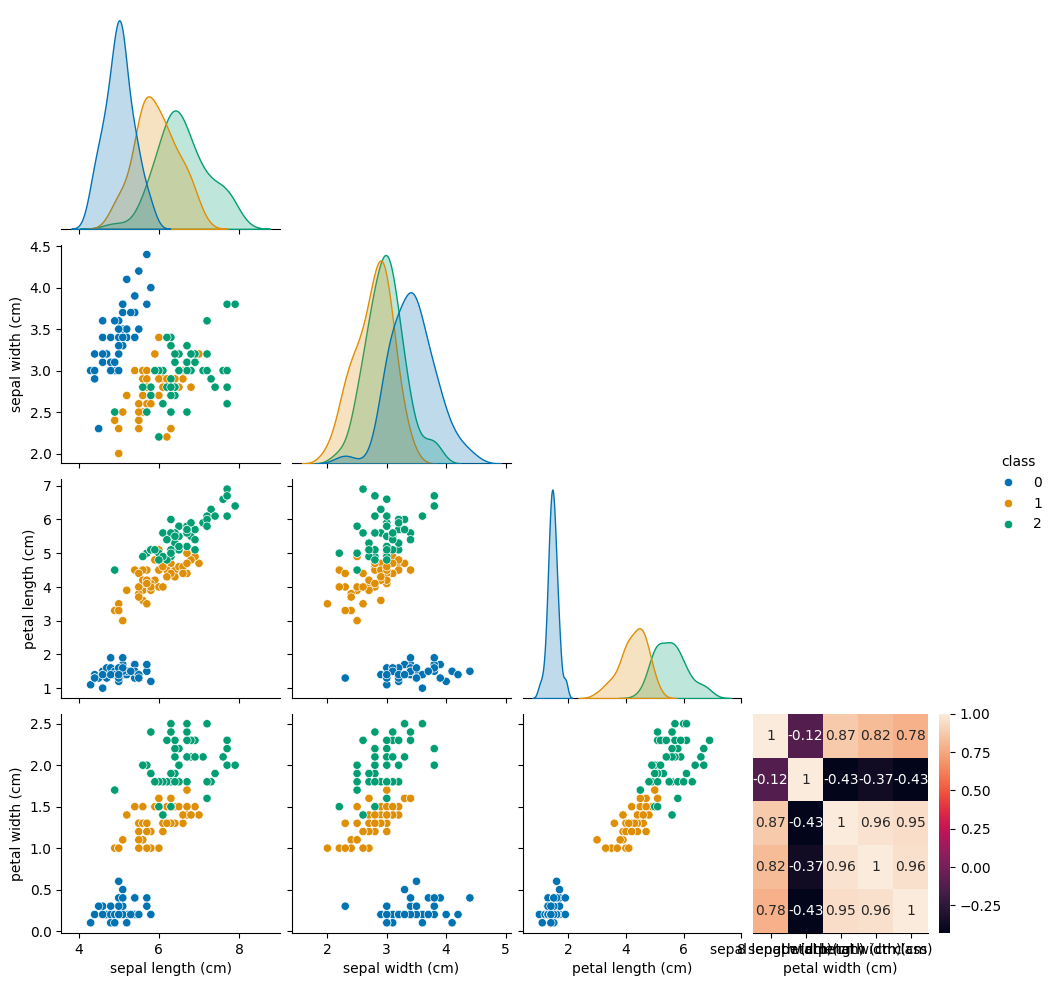

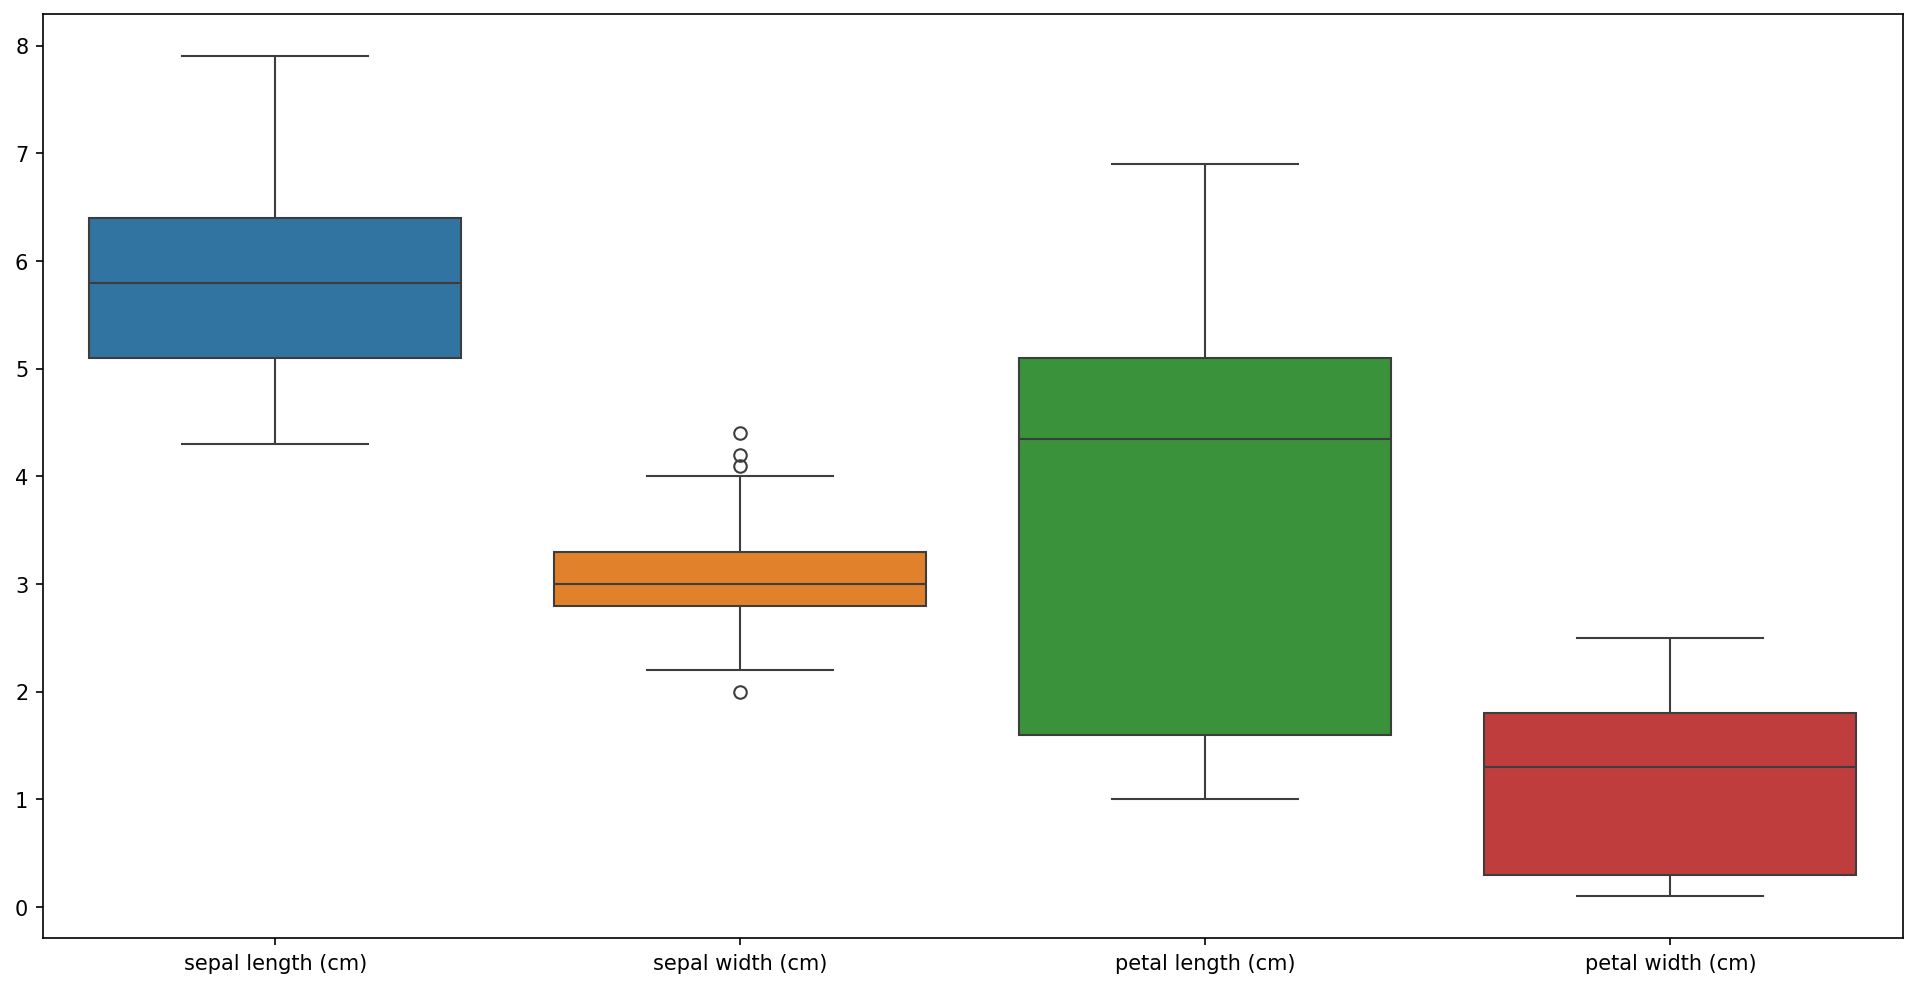

In [95]:
import pandas as pd
from sklearn.datasets import load_iris

# alt for loading
iris = load_iris()

print(iris.keys())


iris["target"]

iris["feature_names"]

iris["target_names"]

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

df_target = pd.DataFrame(iris["target"], columns=["class"])
df_target.head()


df_with_target = pd.concat([df, df_target], axis="columns")
df_with_target.head()

df_with_target.info()

# when testing the algorith wiht some fake data -> get a sense of ranges that we can use
# when validating input data
df_with_target.describe().T # transpose index and columns

import seaborn as sns
# plotting tool to examine data
sns.pairplot(df_with_target, corner=True, hue="class", palette="colorblind")


df_with_target.corr()

import matplotlib.pyplot as plt


sns.heatmap(df_with_target.corr(), annot=True)

fig,ax = plt.subplots(1, figsize=(16,8), dpi=150)

sns.boxplot(df)

q1 = df_with_target["sepal width (cm)"].quantile(.25)
q1


q3 = df_with_target["sepal width (cm)"].quantile(.75)
q3

iqr =  q3-q1
iqr

lower_bound = q1-1.5*iqr
higher_bound = q3+1.5*iqr

lower_bound, higher_bound

(df_with_target["sepal width (cm)"] > lower_bound).sum()


(df_with_target["sepal width (cm)"] < higher_bound).sum()


df_no_outliers = df_with_target[
    (df_with_target["sepal width (cm)"] > lower_bound)
    & (df_with_target["sepal width (cm)"] < higher_bound)
]

df_no_outliers.shape

from sklearn.model_selection import train_test_split

X,y = df_no_outliers.drop("class", axis=1), df_no_outliers["class"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

scaled_X_train.mean(), scaled_X_train.std(), scaled_X_test.mean(), scaled_X_test.std()

In [96]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=1) # kolla vilken int
model.fit(scaled_X_train, y_train)

y_pred = model.predict(scaled_X_test)
y_pred

array([0, 1, 0, 0, 0, 2, 0, 1, 2, 0, 0, 1, 2, 1, 2, 0, 1, 2, 0, 1, 2, 2,
       0, 1, 0, 1, 1, 2, 2, 0, 0, 0, 2, 2, 0, 0, 1, 1, 2, 2, 2, 2, 2, 0,
       2, 2, 0, 0, 2])

In [97]:
y_test.values

array([0, 2, 0, 0, 0, 2, 0, 1, 1, 0, 0, 2, 2, 1, 2, 0, 1, 2, 0, 1, 2, 2,
       0, 1, 0, 1, 1, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 1, 1, 1, 2, 2, 2, 0,
       2, 2, 0, 0, 2])

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.73      0.73      0.73        11
           2       0.84      0.84      0.84        19

    accuracy                           0.88        49
   macro avg       0.86      0.86      0.86        49
weighted avg       0.88      0.88      0.88        49



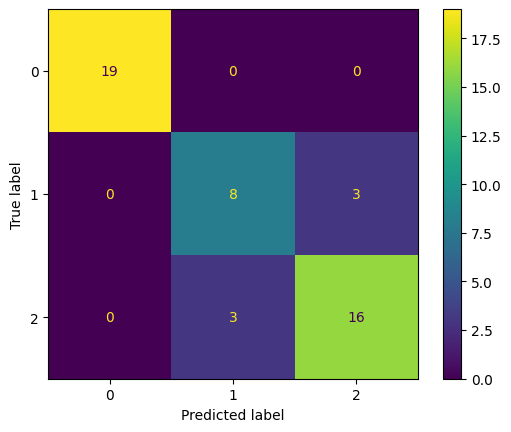

In [98]:
# evaluate model
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(scaled_X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()


b) Use KNN to predict house prices for the dataset you used in exercise1 

In [99]:
df_house_prices = pd.read_csv("../../data/data.csv")
df_house_prices.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [100]:
df_house_prices.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [101]:
df_house_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [102]:
df_house_prices["street"].unique()

array(['18810 Densmore Ave N', '709 W Blaine St',
       '26206-26214 143rd Ave SE', ..., '759 Ilwaco Pl NE',
       '5148 S Creston St', '18717 SE 258th St'],
      shape=(4525,), dtype=object)

In [103]:

df_house_prices["country"].value_counts()

country
USA    4600
Name: count, dtype: int64

In [104]:

# categorical feature that is one-hot encoded - 0 or 1
df_house_prices["waterfront"].value_counts()

waterfront
0    4567
1      33
Name: count, dtype: int64

In [105]:
import duckdb as db

query = db.query (
    """
    SELECT
        AVG(price) AS avg_price,
        condition
    FROM
        df_house_prices
    GROUP BY
        2
    ORDER BY 
        avg_price DESC
    """
).df()

query

,avg_price,condition
0,637041.322258,5
1,550111.516394,3
2,533647.286072,4
3,324373.750000,2
4,306633.333333,1


In [106]:
# cleaning
df_cleaned = df_house_prices.drop(
    ["country", "statezip", "city", "street", "date"], axis="columns"
)  # view?

df_cleaned["yr_renovated"] = df_cleaned.apply(
    lambda row: row["yr_built"] if not row["yr_renovated"] else row["yr_renovated"], axis=1
)
df_cleaned.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005.0
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,1921.0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,1966.0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,1963.0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992.0


TODO: kolla values och rätt variabelnamn

In [107]:
# calculating upper and lower limits by percentiles and filtering out the outliers
lower_limit = df_cleaned["price"].quantile(0.01)
upper_limit = df_cleaned["price"].quantile(0.99)

df_filtered = df_cleaned[(df_cleaned["price"] >= lower_limit) & (df_cleaned["price"] <= upper_limit)]

print(f"rows after filtering: {df_filtered[0]} rows")
print(f"lower : {lower_limit:,.0f}  |  upper: {upper_limit:,.0f}")

KeyError: 0

In [ ]:
X, y = df_cleaned.drop("price", axis=1), df_cleaned["price"]

X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005.0
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,1921.0
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,1966.0
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,1963.0
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

X_train.shape, X_test.shape

((3082, 12), (1518, 12))

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# scaler.fit(X_train)
# scaled_X_train = scaler.transform(X_train)
# scaled_X_test = scaler.transform(X_test)

scaler = MinMaxScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)
scaled_X_train.mean(), scaled_X_train.std(), scaled_X_test.mean(), scaled_X_test.std()

(np.float64(0.28267520127895557),
 np.float64(0.29051501959073034),
 np.float64(0.2850243714535379),
 np.float64(0.29312528824511114))

In [ ]:
model_KNN = KNeighborsRegressor(n_neighbors=1)
model_KNN.fit(scaled_X_train, y_train)
y_pred = model_KNN.predict(scaled_X_test)
y_pred

array([584000., 280000., 720000., ..., 435000., 375000., 725000.],
      shape=(1518,))

In [ ]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# cm = confusion_matrix(y_test, y_pred)
# ConfusionMatrixDisplay(cm).plot()

In [ ]:
# print(classification_report(y_test, y_pred))

In [ ]:
error = 1-accuracy_score(y_test, y_pred)
error_list = []

for k in range(1,50):
    model_KNN = KNeighborsClassifier(n_neighbors=k)
    model_KNN.fit(scaled_X_train, y_train)
    y_pred = model_KNN.predict(scaled_X_test)
    error_list.append(1-accuracy_score(y_test, y_pred))

fig, ax = plt.figure(), plt.axes()
ax.plot(range(1, len(error_list)+1), error_list, ".-")
ax.set(title="Elbow plot", xlabel = "k neightbours", ylabel= "Error")

NameError: name 'accuracy_score' is not defined

In [ ]:
# we choose k = 11 here
model_KNN = KNeighborsClassifier(11)
model_KNN.fit(scaled_X_train, y_train)
y_pred = model_KNN.predict(scaled_X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()